# NHANES – Porównanie modeli klasyfikacji cukrzycy
Trzy modele trenowane na zbiorze NHANES 2017-2018. Wyniki przedstawione obok siebie.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    precision_recall_curve, average_precision_score, f1_score
)
from imblearn.over_sampling import SMOTE
import lightgbm as lgb
import xgboost as xgb

RANDOM_STATE = 42

## Wczytanie i przygotowanie danych

In [105]:
# cykl 2017-2018
demo = pd.read_sas(r"DEMO_J.xpt.txt", format="xport") #dane demograficzne
bmx = pd.read_sas(r"BMX_J.xpt.txt", format="xport") #BMI
bpx = pd.read_sas(r"BPX_J.xpt.txt", format="xport") #cisnienie
glu = pd.read_sas(r"GLU_J.xpt.txt", format="xport")  # glukosa na czco w osoczu
diq = pd.read_sas(r"DIQ_J.xpt.txt", format="xport") #czy zdiagnozowany na cukrzyce 
ins = pd.read_sas(r"INS_J.xpt.txt", format="xport") #insulina
chol = pd.read_sas(r"TCHOL_J.xpt.txt", format="xport") #cholesterol
ldl = pd.read_sas(r"TRIGLY_J.xpt.txt", format="xport") #LDL

#połączenie – rozszerzony zbiór cech 
df2 = demo.merge(bmx, on="SEQN")
df2 = df2.merge(bpx, on="SEQN")
df2 = df2.merge(glu, on="SEQN")
df2 = df2.merge(diq, on="SEQN")
df2 = df2.merge(ins, on="SEQN")
df2 = df2.merge(chol, on="SEQN")
df2 = df2.merge(ldl, on="SEQN")

#połączenie – podstawowy zbiór cech (model1)
df1 = demo.merge(bmx, on="SEQN")
df1 = df1.merge(bpx, on="SEQN")
df1 = df1.merge(glu, on="SEQN")
df1 = df1.merge(diq, on="SEQN")
df1 = df1.merge(ins, on="SEQN")

print(f"Rekordów df1: {len(df1)}, df2: {len(df2)}")

Rekordów df1: 3036, df2: 3036


In [106]:
def prepare_dataset(df, features):
    data = df[features + ["DIQ010"]].copy()
    data = data[data["DIQ010"].isin([1, 2])]
    data["diabetes"] = (data["DIQ010"] == 1).astype(int)
    data = data.drop(columns=["DIQ010"]).dropna()
    return data

features_basic = ["RIDAGEYR", "RIAGENDR", "BMXBMI", "BPXSY1", "LBXGLU"]
features_ext   = ["RIDAGEYR", "RIAGENDR", "BMXBMI", "BMXWAIST", "BPXSY1", "LBXGLU", "LBXIN", "LBXTC"]

data1 = prepare_dataset(df1, features_basic)
data2 = prepare_dataset(df2, features_ext)

print(f"data1: {data1.shape}, cukrzyca: {data1.diabetes.sum()} ({data1.diabetes.mean()*100:.1f}%)")
print(f"data2: {data2.shape}, cukrzyca: {data2.diabetes.sum()} ({data2.diabetes.mean()*100:.1f}%)")

data1: (2460, 6), cukrzyca: 354 (14.4%)
data2: (2343, 9), cukrzyca: 335 (14.3%)


## Trenowanie modeli
### Logistic Regression – podstawowe cechy

In [107]:
X1 = data1.drop(columns=["diabetes"])
y1 = data1["diabetes"]

X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=RANDOM_STATE, stratify=y1)

scaler1 = StandardScaler()
X1_train_sc = scaler1.fit_transform(X1_train)
X1_test_sc  = scaler1.transform(X1_test)

lr1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr1.fit(X1_train_sc, y1_train)

y1_pred = lr1.predict(X1_test_sc)
y1_prob = lr1.predict_proba(X1_test_sc)[:, 1]


### Logistic Regression – rozszerzone cechy

In [108]:
X2 = data2.drop(columns=["diabetes"])
y2 = data2["diabetes"]

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

lr2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr2.fit(X2_train_sc, y2_train)

y2_pred = lr2.predict(X2_test_sc)
y2_prob = lr2.predict_proba(X2_test_sc)[:, 1]

### LightGBM + SMOTE

In [109]:
smote = SMOTE(random_state=RANDOM_STATE)
X2_train_sm, y2_train_sm = smote.fit_resample(X2_train, y2_train)

lgbm = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.05, num_leaves=31, max_depth=-1, random_state=RANDOM_STATE, verbosity=-1)
lgbm.fit(X2_train_sm, y2_train_sm)

y_lgbm_pred = lgbm.predict(X2_test)
y_lgbm_prob = lgbm.predict_proba(X2_test)[:, 1]


### XGBoost + SMOTE

In [110]:
X2_train_xg, X2_test_xg, y2_train_xg, y2_test_xg = train_test_split(
    X2, y2, test_size=0.2, random_state=RANDOM_STATE, stratify=y2)

sm2 = SMOTE(random_state=RANDOM_STATE)
X2_train_xgsm, y2_train_xgsm = sm2.fit_resample(X2_train_xg, y2_train_xg)

xgboost = xgb.XGBClassifier(objective='binary:logistic', n_estimators=100,learning_rate=0.1, max_depth=4, eval_metric='logloss', random_state=RANDOM_STATE)
xgboost.fit(X2_train_xgsm, y2_train_xgsm)

y_xgb_pred = xgboost.predict(X2_test_xg)
y_xgb_prob = xgboost.predict_proba(X2_test_xg)[:, 1]

---
## Metryki 

In [111]:
models = [
    ("LR (podstawowe)",  y1_test, y1_pred, y1_prob),
    ("LR (rozszerzone)", y2_test, y2_pred, y2_prob),
    ("LightGBM",         y2_test, y_lgbm_pred, y_lgbm_prob),
    ("XGBoost",          y2_test_xg, y_xgb_pred, y_xgb_prob),
]

rows = []
for name, yt, yp, ypr in models:
    rep = classification_report(yt, yp, output_dict=True)
    rows.append({
        "Model"        : name,
        "Accuracy"     : round(accuracy_score(yt, yp), 4),
        "ROC AUC"      : round(roc_auc_score(yt, ypr), 4),
        "Avg Precision": round(average_precision_score(yt, ypr), 4),
        "F1 (macro)"   : round(f1_score(yt, yp, average='macro'), 4),
        "Precision (1)": round(rep['1']['precision'], 4),
        "Recall (1)"   : round(rep['1']['recall'], 4),
        "F1 (1)"       : round(rep['1']['f1-score'], 4),
    })

results_df = pd.DataFrame(rows).set_index("Model")
print(results_df.to_string())

                  Accuracy  ROC AUC  Avg Precision  F1 (macro)  Precision (1)  Recall (1)  F1 (1)
Model                                                                                            
LR (podstawowe)     0.8699   0.9346         0.7997      0.7879         0.5304      0.8592  0.6559
LR (rozszerzone)    0.8721   0.9252         0.7919      0.7883         0.5327      0.8507  0.6552
LightGBM            0.9147   0.9350         0.7953      0.8301         0.6901      0.7313  0.7101
XGBoost             0.9147   0.9362         0.7685      0.8359         0.6753      0.7761  0.7222


---
## Wizualizacje 

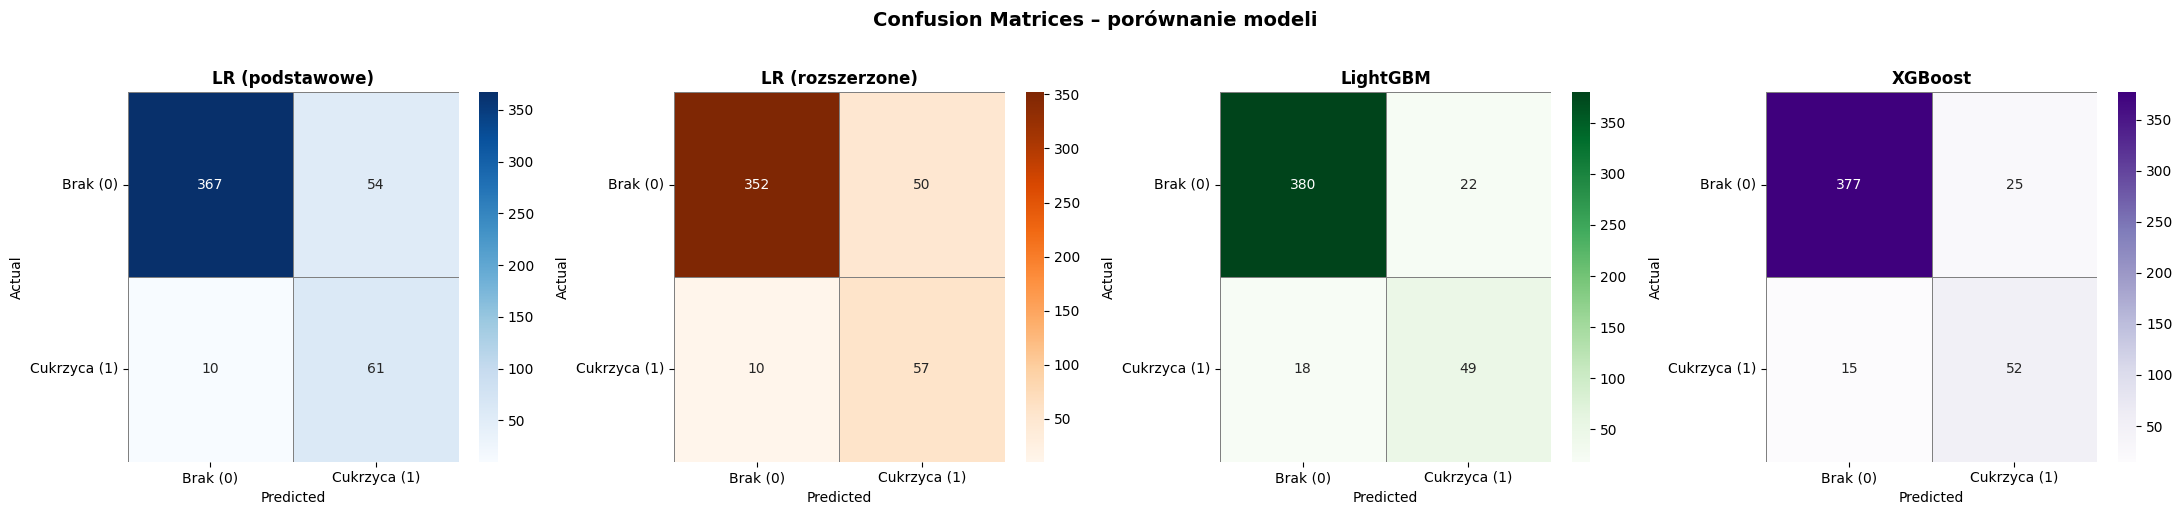

In [112]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
cmaps = ['Blues', 'Oranges', 'Greens', 'Purples']

for ax, (name, yt, yp, _), cmap in zip(axes, models, cmaps):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax, linewidths=0.5, linecolor='grey')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticklabels(['Brak (0)', 'Cukrzyca (1)'])
    ax.set_yticklabels(['Brak (0)', 'Cukrzyca (1)'], rotation=0)

fig.suptitle('Confusion Matrices – porównanie modeli', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

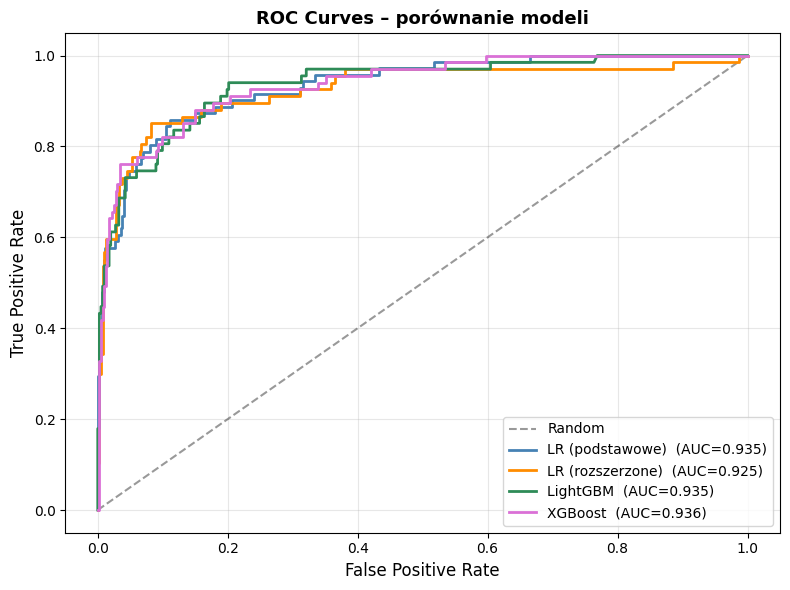

In [113]:
colors = ['steelblue', 'darkorange', 'seagreen', 'orchid']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')

for (name, yt, _, ypr), c in zip(models, colors):
    fpr, tpr, _ = roc_curve(yt, ypr)
    auc = roc_auc_score(yt, ypr)
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{name}  (AUC={auc:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves – porównanie modeli', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

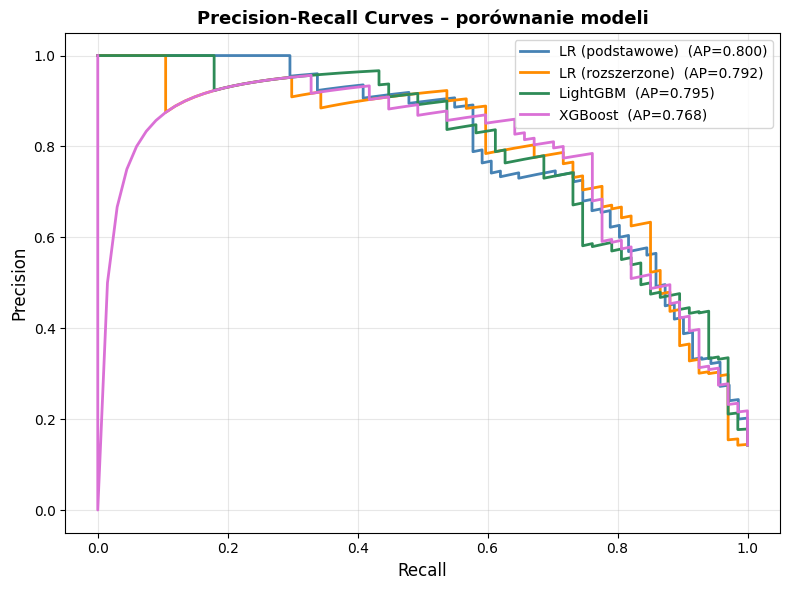

In [114]:
fig, ax = plt.subplots(figsize=(8, 6))

for (name, yt, _, ypr), c in zip(models, colors):
    prec, rec, _ = precision_recall_curve(yt, ypr)
    ap = average_precision_score(yt, ypr)
    ax.plot(rec, prec, color=c, lw=2, label=f'{name}  (AP={ap:.3f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves – porównanie modeli', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

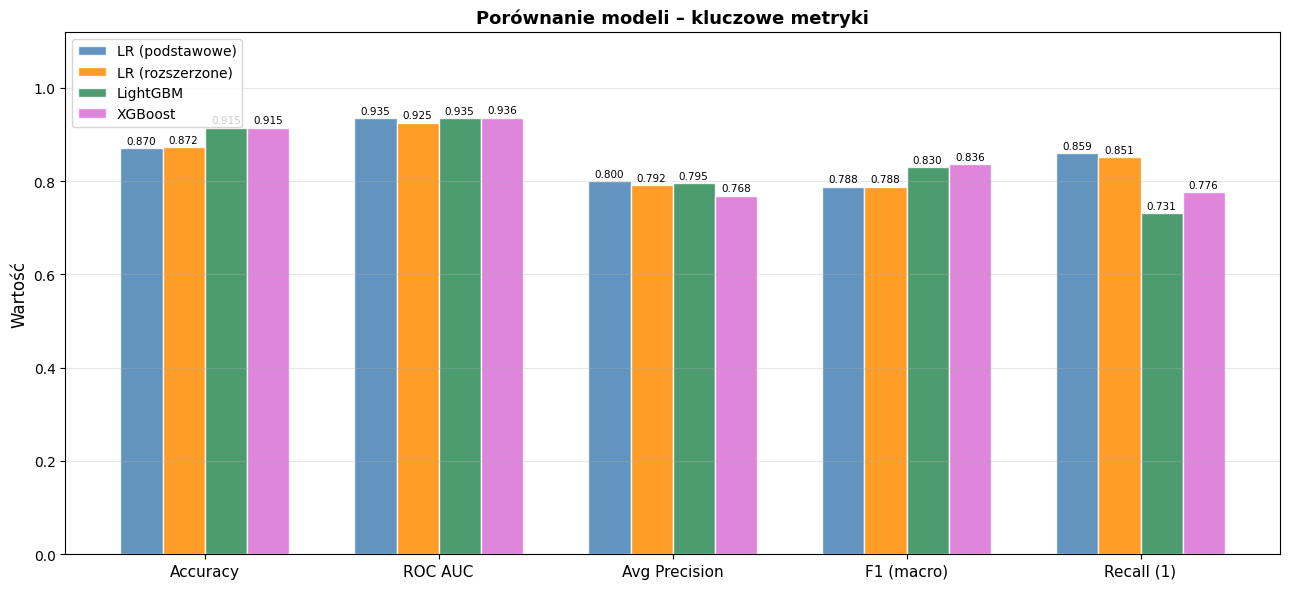

In [115]:
metrics_to_plot = ['Accuracy', 'ROC AUC', 'Avg Precision', 'F1 (macro)', 'Recall (1)']
plot_df = results_df[metrics_to_plot]

x = np.arange(len(metrics_to_plot))
width = 0.18
n = len(plot_df)

fig, ax = plt.subplots(figsize=(13, 6))
for i, (model_name, row) in enumerate(plot_df.iterrows()):
    offset = (i - n / 2 + 0.5) * width
    bars = ax.bar(x + offset, row.values, width, label=model_name, color=colors[i], alpha=0.85, edgecolor='white')
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Wartość', fontsize=12)
ax.set_title('Porównanie modeli – kluczowe metryki', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

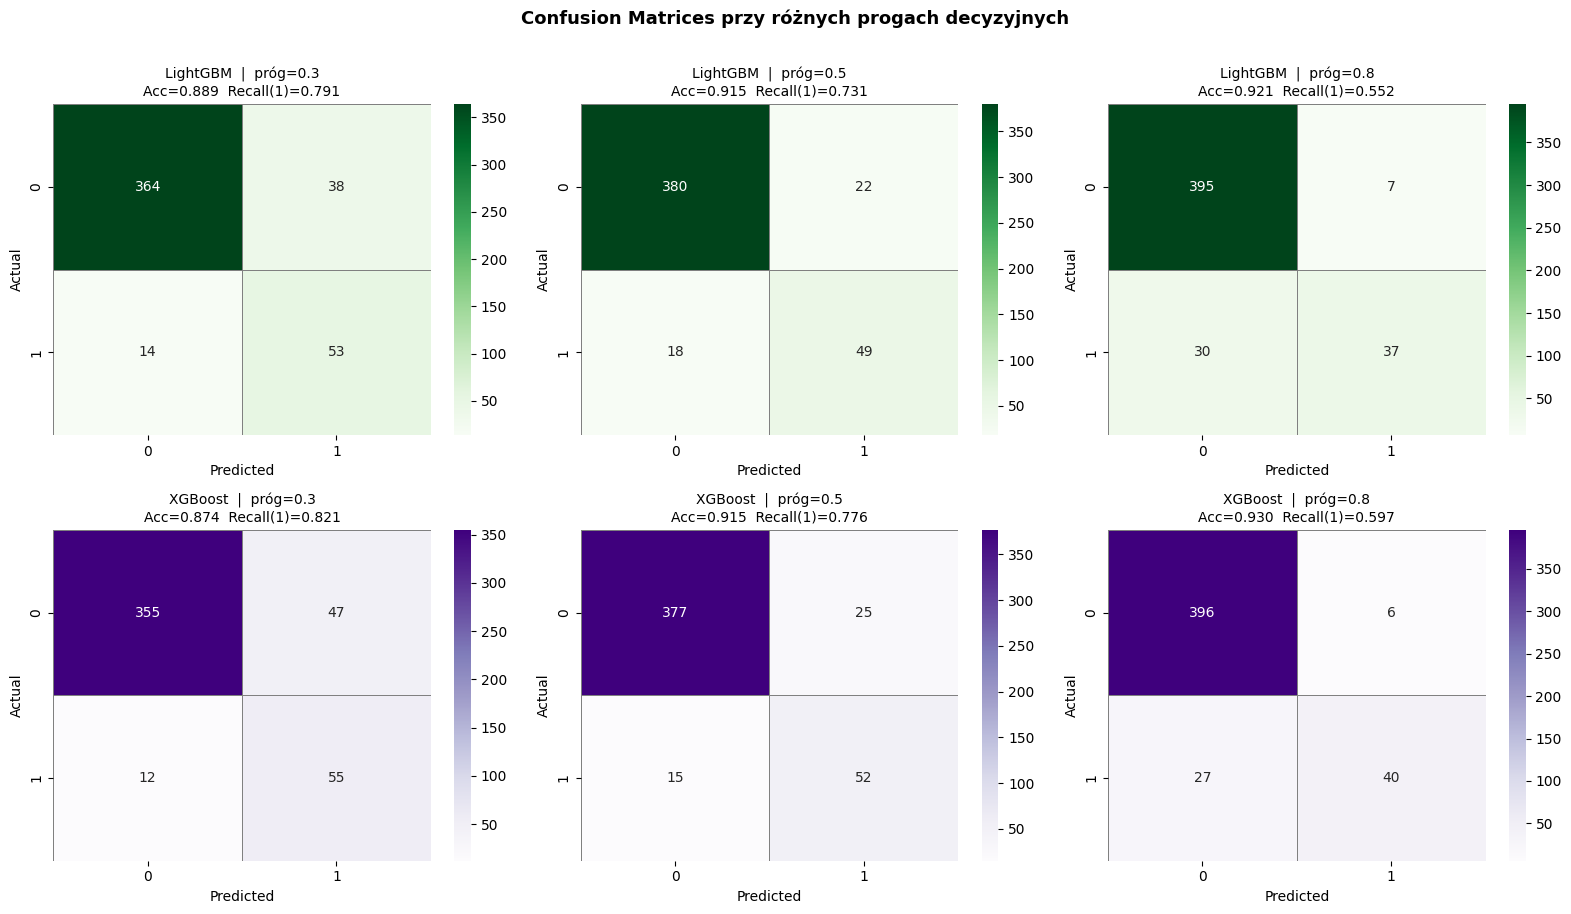

In [116]:
thresholds = [0.3, 0.5, 0.8]
boost_models = [
    ("LightGBM", y2_test, y_lgbm_prob),
    ("XGBoost",  y2_test_xg, y_xgb_prob),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
cmaps2 = ['Greens', 'Purples']

for row_idx, (mname, yt, ypr) in enumerate(boost_models):
    for col_idx, thr in enumerate(thresholds):
        ax = axes[row_idx][col_idx]
        yp_thr = (ypr > thr).astype(int)
        cm = confusion_matrix(yt, yp_thr)
        sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps2[row_idx], ax=ax, linewidths=0.5, linecolor='grey')
        acc = accuracy_score(yt, yp_thr)
        rec = cm[1, 1] / (cm[1, 0] + cm[1, 1]) if (cm[1, 0] + cm[1, 1]) > 0 else 0
        ax.set_title(f'{mname}  |  próg={thr}\nAcc={acc:.3f}  Recall(1)={rec:.3f}', fontsize=10)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')

fig.suptitle('Confusion Matrices przy różnych progach decyzyjnych', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

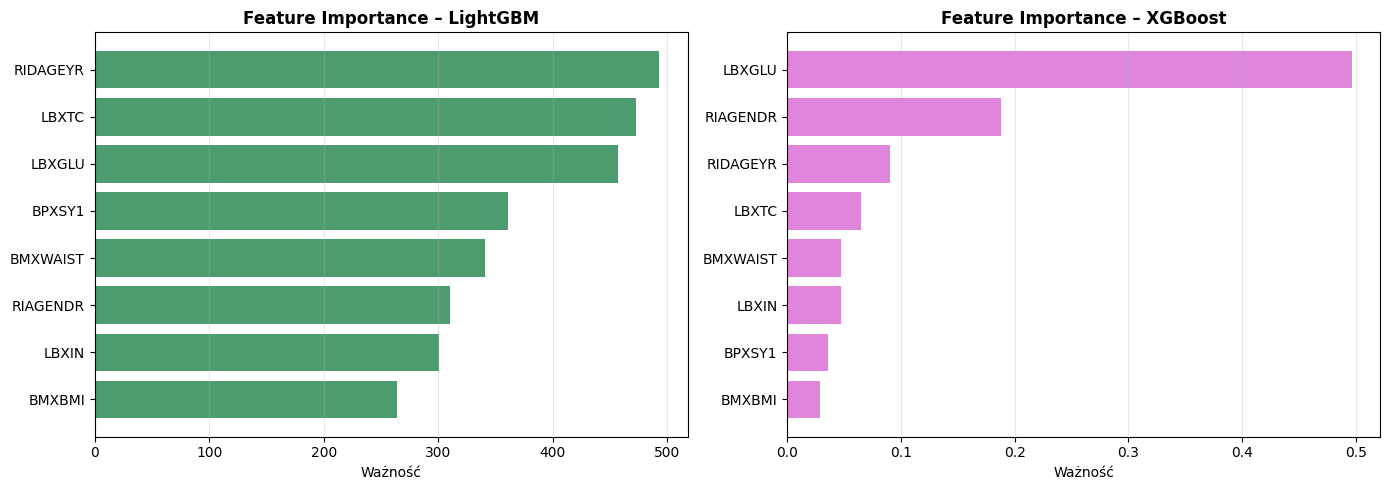

In [117]:
feat_names = list(X2.columns)

fi_lgbm = pd.DataFrame({'Feature': feat_names, 'Importance': lgbm.feature_importances_})\
            .sort_values('Importance', ascending=True)

fi_xgb  = pd.DataFrame({'Feature': feat_names, 'Importance': xgboost.feature_importances_})\
            .sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(fi_lgbm['Feature'], fi_lgbm['Importance'], color='seagreen', alpha=0.85)
axes[0].set_title('Feature Importance – LightGBM', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Ważność')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(fi_xgb['Feature'], fi_xgb['Importance'], color='orchid', alpha=0.85)
axes[1].set_title('Feature Importance – XGBoost', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Ważność')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

---
## Tabela wynikowa – podsumowanie

In [118]:
styled = results_df.style\
    .background_gradient(cmap='YlGn', axis=0)\
    .format("{:.4f}")\
    .set_caption("Podsumowanie metryk – wszystkie modele")
styled

,Accuracy,ROC AUC,Avg Precision,F1 (macro),Precision (1),Recall (1),F1 (1)
Model,,,,,,,
LR (podstawowe),0.8699,0.9346,0.7997,0.7879,0.5304,0.8592,0.6559
LR (rozszerzone),0.8721,0.9252,0.7919,0.7883,0.5327,0.8507,0.6552
LightGBM,0.9147,0.9350,0.7953,0.8301,0.6901,0.7313,0.7101
XGBoost,0.9147,0.9362,0.7685,0.8359,0.6753,0.7761,0.7222


In [119]:
#classification report 
sep = "-" * 55
for name, yt, yp, ypr in models:
    print(f"\n{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"  Accuracy : {accuracy_score(yt, yp):.4f}")
    print(f"  ROC AUC  : {roc_auc_score(yt, ypr):.4f}")
    print(f"  Avg Prec : {average_precision_score(yt, ypr):.4f}")
    print(sep)
    print(classification_report(yt, yp, target_names=['Brak cukrzycy','Cukrzyca']))


  LR (podstawowe)
  Accuracy : 0.8699
  ROC AUC  : 0.9346
  Avg Prec : 0.7997
-------------------------------------------------------
               precision    recall  f1-score   support

Brak cukrzycy       0.97      0.87      0.92       421
     Cukrzyca       0.53      0.86      0.66        71

     accuracy                           0.87       492
    macro avg       0.75      0.87      0.79       492
 weighted avg       0.91      0.87      0.88       492


  LR (rozszerzone)
  Accuracy : 0.8721
  ROC AUC  : 0.9252
  Avg Prec : 0.7919
-------------------------------------------------------
               precision    recall  f1-score   support

Brak cukrzycy       0.97      0.88      0.92       402
     Cukrzyca       0.53      0.85      0.66        67

     accuracy                           0.87       469
    macro avg       0.75      0.86      0.79       469
 weighted avg       0.91      0.87      0.88       469


  LightGBM
  Accuracy : 0.9147
  ROC AUC  : 0.9350
  Avg Prec 

---
## SHAP

In [120]:
import shap

explainer_lgbm = shap.TreeExplainer(lgbm)
shap_lgbm = explainer_lgbm.shap_values(X2_test)
# lightgbmzwraca listę [klasa0, klasa1] – bierzemy klasę 1
if isinstance(shap_lgbm, list):
    shap_lgbm = shap_lgbm[1]

explainer_xgb = shap.TreeExplainer(xgboost)
shap_xgb = explainer_xgb.shap_values(X2_test_xg)

c:\Users\ppusk\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\explainers\_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


### Summary Plot

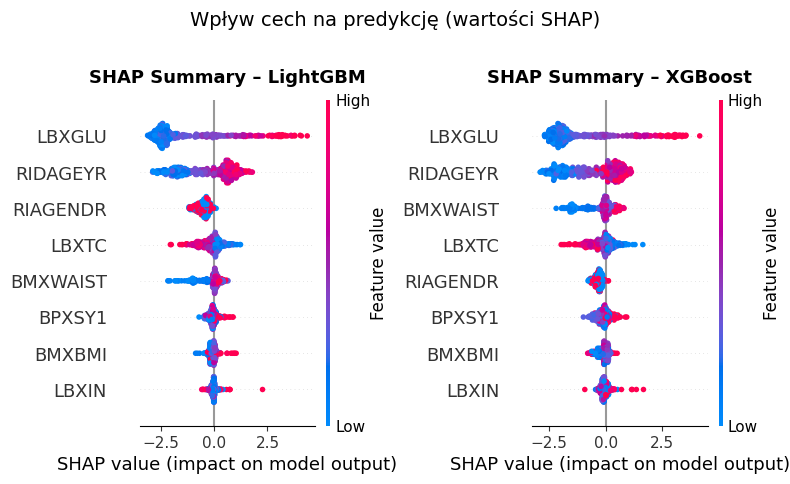

In [121]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

plt.sca(axes[0])
shap.summary_plot(shap_lgbm, X2_test, feature_names=list(X2.columns), plot_type='dot', show=False)
axes[0].set_title('SHAP Summary – LightGBM', fontsize=13, fontweight='bold', pad=12)

plt.sca(axes[1])
shap.summary_plot(shap_xgb, X2_test_xg, feature_names=list(X2.columns), plot_type='dot', show=False)
axes[1].set_title('SHAP Summary – XGBoost', fontsize=13, fontweight='bold', pad=12)

plt.suptitle('Wpływ cech na predykcję (wartości SHAP)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Średnia ważność cech

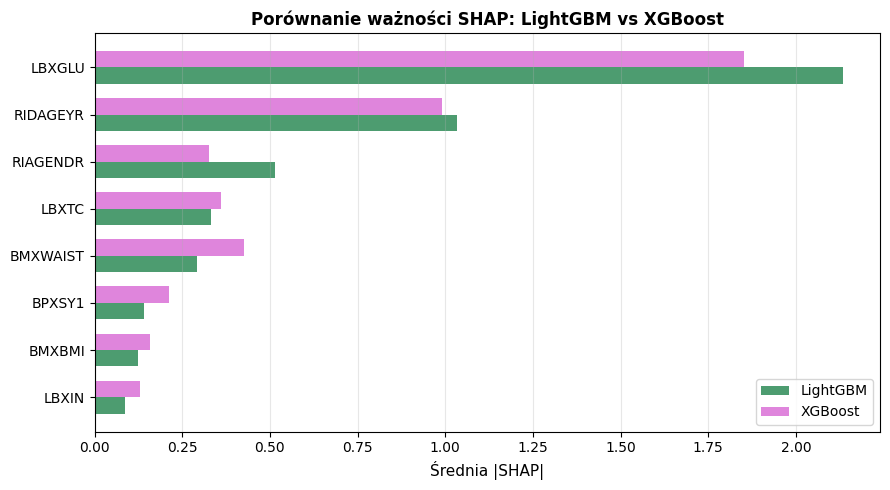

In [122]:
shap_compare = pd.DataFrame({
    'Feature'  : feat_names,
    'LightGBM' : mean_shap_lgbm,
    'XGBoost'  : mean_shap_xgb
}).sort_values('LightGBM', ascending=True)

x = np.arange(len(feat_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(x - width/2, shap_compare['LightGBM'], width, label='LightGBM', color='seagreen', alpha=0.85)
ax.barh(x + width/2, shap_compare['XGBoost'],  width, label='XGBoost',  color='orchid',   alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(shap_compare['Feature'], fontsize=10)
ax.set_xlabel('Średnia |SHAP|', fontsize=11)
ax.set_title('Porównanie ważności SHAP: LightGBM vs XGBoost', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Waterfall - krok po kroku jak każda cecha wpłyneła na predykcję dla konkretnego pacjenta

In [123]:
exp_lgbm = shap.Explainer(lgbm, X2_test)
shap_exp_lgbm = exp_lgbm(X2_test)

exp_xgb = shap.Explainer(xgboost, X2_test_xg)
shap_exp_xgb = exp_xgb(X2_test_xg)

### Predykcja dla jednego pacjenta

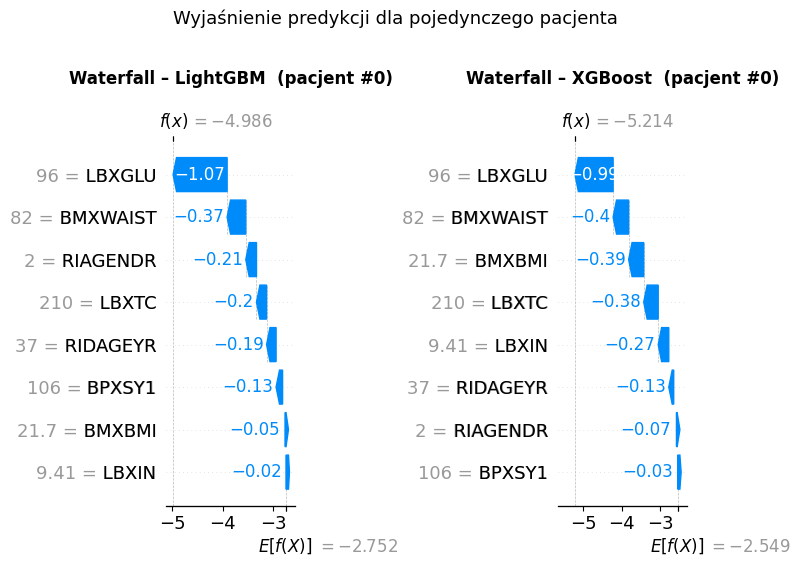

In [124]:
patient_idx = 0

fig, axes = plt.subplots(1, 2, figsize=(28, 12), dpi=100)

plt.sca(axes[0])
shap.plots.waterfall(shap_exp_lgbm[patient_idx], show=False)
axes[0].set_title(f'Waterfall – LightGBM  (pacjent #{patient_idx})', fontsize=12, fontweight='bold', pad=20)

plt.sca(axes[1])
shap.plots.waterfall(shap_exp_xgb[patient_idx], show=False)
axes[1].set_title(f'Waterfall – XGBoost  (pacjent #{patient_idx})', fontsize=12, fontweight='bold', pad=20)

plt.suptitle('Wyjaśnienie predykcji dla pojedynczego pacjenta', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### Predykcja dla czterech pacjentów - dwóch z cukrzycą i dwóch bez

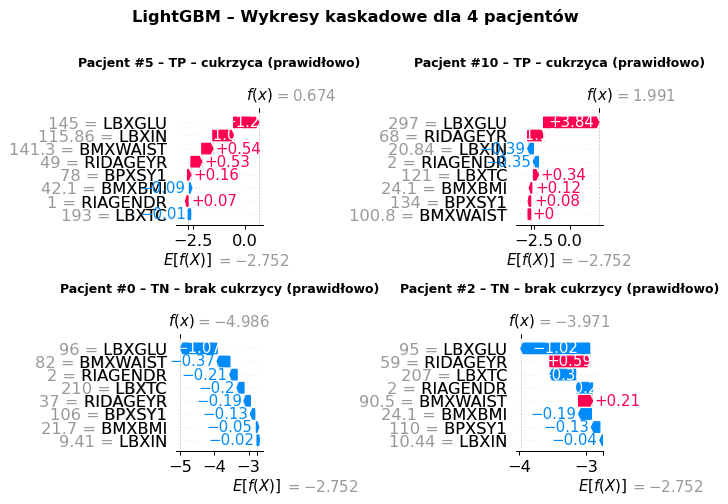

In [125]:
y2_test_arr = np.array(y2_test)
y_lgbm_pred_arr = np.array(y_lgbm_pred)

tp_idx = np.where((y2_test_arr == 1) & (y_lgbm_pred_arr == 1))[0][:2]
tn_idx = np.where((y2_test_arr == 0) & (y_lgbm_pred_arr == 0))[0][:2]
selected = list(tp_idx) + list(tn_idx)
labels = ['TP – cukrzyca (prawidłowo)', 'TP – cukrzyca (prawidłowo)',
          'TN – brak cukrzycy (prawidłowo)', 'TN – brak cukrzycy (prawidłowo)']

fig, axes = plt.subplots(2, 2, figsize=(28, 18), dpi=90)
axes = axes.flatten()

for plot_i, (pat_i, label) in enumerate(zip(selected, labels)):
    plt.sca(axes[plot_i])
    shap.plots.waterfall(shap_exp_lgbm[pat_i], show=False)
    axes[plot_i].set_title(f'Pacjent #{pat_i} – {label}', fontsize=10, fontweight='bold', pad=15)

plt.suptitle('LightGBM – Wykresy kaskadowe dla 4 pacjentów', fontsize=13, fontweight='bold', y=1.01)
#plt.subplots_adjust(wspace=0.6, hspace=0.4)
plt.tight_layout()
plt.show()

### Gdzie model się myli

False Positives: 22,  False Negatives: 18


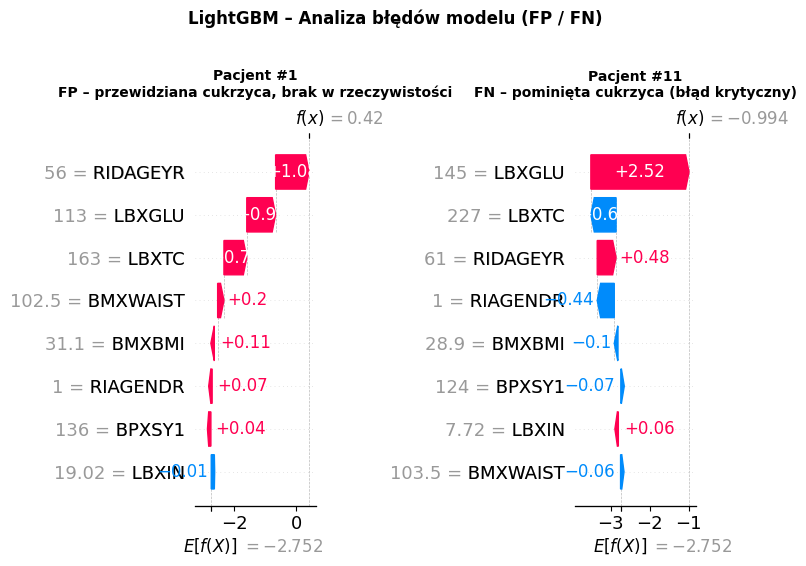

In [126]:
fp_idx = np.where((y2_test_arr == 0) & (y_lgbm_pred_arr == 1))[0]
fn_idx = np.where((y2_test_arr == 1) & (y_lgbm_pred_arr == 0))[0]

print(f"False Positives: {len(fp_idx)},  False Negatives: {len(fn_idx)}")

error_cases = []
error_labels = []
if len(fp_idx) > 0:
    error_cases.append(fp_idx[0])
    error_labels.append('FP – przewidziana cukrzyca, brak w rzeczywistości')
if len(fn_idx) > 0:
    error_cases.append(fn_idx[0])
    error_labels.append('FN – pominięta cukrzyca (błąd krytyczny)')

n_cases = len(error_cases)
if n_cases > 0:
    fig, axes = plt.subplots(1, n_cases, figsize=(9 * n_cases, 5))
    if n_cases == 1:
        axes = [axes]
    for ax, pat_i, label in zip(axes, error_cases, error_labels):
        plt.sca(ax)
        shap.plots.waterfall(shap_exp_lgbm[pat_i], show=False)
        ax.set_title(f'Pacjent #{pat_i}\n{label}', fontsize=10, fontweight='bold', pad=8)
    plt.suptitle('LightGBM – Analiza błędów modelu (FP / FN)', fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print("Brak błędów do wyświetlenia.")